<a href="https://colab.research.google.com/github/monikasingh1109/llm-agentic-forecasting/blob/main/Walmart_Agentic_Forecast_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agentic LLM forecasting: Walmart weekly sales (Colab notebook)
Runs the project code stage by stage so you can see and screenshot every result.
**Run top to bottom.** Needs: `walmart-agentic-forecast.zip`, your `Walmart.csv`, and a Gemini key in Colab *Secrets* (name `GOOGLE_API_KEY`).
Maps to your checklist: setup C2-04 · audit C4-03 · EDA C5-01 · baselines C5-03 · ML + DM test C5-04 · SHAP C5-05 · agent C5-06/07.

## 0. Setup

In [1]:
import os, sys, subprocess, pathlib, json
IN_COLAB = "google.colab" in sys.modules
FAST = os.environ.get("NB_FAST") == "1"          # quick test mode (skips Prophet)
if IN_COLAB:
    from google.colab import files
    if not pathlib.Path("walmart-agentic-forecast").exists():
        print("Upload walmart-agentic-forecast.zip"); files.upload()
        subprocess.run(["unzip", "-q", "-o", "walmart-agentic-forecast.zip"], check=True)
    os.chdir("walmart-agentic-forecast")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
sys.path.insert(0, str(pathlib.Path("src").resolve()))
print("cwd:", os.getcwd())

Upload walmart-agentic-forecast.zip


Saving walmart-agentic-forecast.zip to walmart-agentic-forecast.zip
cwd: /content/walmart-agentic-forecast


## 1. Data
Upload `Walmart.csv` (the 45-store Kaggle file). It is saved to `data/raw/` (Colab files vanish when the runtime resets, so keep your own copy).

In [2]:
raw_dir = pathlib.Path(os.environ.get("WFA_DATA_DIR", "data/raw")); raw_dir.mkdir(parents=True, exist_ok=True)
if IN_COLAB and not any(raw_dir.glob("*.csv")):
    up = files.upload()
    for name, content in up.items():
        (raw_dir / ("Walmart.csv" if len(up) == 1 else name)).write_bytes(content)
print(sorted(p.name for p in raw_dir.glob("*.csv")))

Saving walmart-sales-dataset-of-45stores.csv to walmart-sales-dataset-of-45stores.csv
['Walmart.csv']


## 2. Keys and settings
The key is read from Colab *Secrets* (left sidebar, key icon), never typed into the notebook.

In [3]:
if IN_COLAB:
    from google.colab import userdata
    try:
        os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    except Exception as e:
        print("No GOOGLE_API_KEY secret found; the agent will fail unless you use LLM_PROVIDER=mock:", e)
os.environ.setdefault("LLM_PROVIDER", "gemini")          # gemini | groq | mock
os.environ.setdefault("GEMINI_MODEL", "gemini-2.5-flash") # check the current name in Google AI Studio
from wfa import config as C, pipeline as P
C.ensure_dirs()
print("data:", C.DATA_DIR, "| outputs:", C.OUT_DIR, "| LLM:", os.environ["LLM_PROVIDER"])

No GOOGLE_API_KEY secret found; the agent will fail unless you use LLM_PROVIDER=mock: Secret GOOGLE_API_KEY does not exist.
data: /content/walmart-agentic-forecast/data/raw | outputs: /content/walmart-agentic-forecast/outputs | LLM: gemini


## 3. Load data and look at it

In [4]:
raw, sw, fut = P.load()
print(sw.shape, "| stores:", sw.Store.nunique(), "| weeks:", sw.Date.nunique(), "| future rows:", len(fut),
      "| assumed future drivers:", fut.attrs.get("assumed_exogenous"))
sw.head()

NOTE: single-file variant detected. Store Type = sales tier from the first 52 weeks (proxy, not Walmart's official type); Size, Dept and MarkDown1-5 do not exist in this file; future drivers will be ASSUMED (see build_future_frame).
(6435, 11) | stores: 45 | weeks: 143 | future rows: 540 | assumed future drivers: True


,Store,Date,y,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size,HolidayType
0,1,2010-02-05,1643690.90,False,42.31,2.572,211.096358,8.106,A,NaN,None
1,1,2010-02-12,1641957.44,True,38.51,2.548,211.242170,8.106,A,NaN,SuperBowl
2,1,2010-02-19,1611968.17,False,39.93,2.514,211.289143,8.106,A,NaN,None
3,1,2010-02-26,1409727.59,False,46.63,2.561,211.319643,8.106,A,NaN,None
4,1,2010-03-05,1554806.68,False,46.50,2.625,211.350143,8.106,A,NaN,None


## 4. Data quality audit (slide 12)

In [5]:
from IPython.display import Markdown, display
res = P.stage_audit()
display(Markdown((C.OUT_DIR / "data_quality_report.md").read_text()))

NOTE: single-file variant detected. Store Type = sales tier from the first 52 weeks (proxy, not Walmart's official type); Size, Dept and MarkDown1-5 do not exist in this file; future drivers will be ASSUMED (see build_future_frame).


# Data quality report

Period: 2010-02-05 to 2012-10-26  |  Stores: 45  |  Departments: 1

## Findings
- Duplicate (Store, Dept, Date) rows: **0** (removed)
- Negative weekly sales rows (kept; returns): **0** (0.0 %)
- Zero sales rows: 0
- Stores with missing weeks: 0 (weeks per store 143-143)
- Negative values after aggregating to store-week: 0
- Features with missing values (%): {}

## Before / after counts

| Step                                 |   Before |   After | Action                      |
|:-------------------------------------|---------:|--------:|:----------------------------|
| train.csv rows (store x dept x week) |     6435 |    6435 | duplicates removed          |
| Store-week rows used for modelling   |     6435 |    6435 | aggregated over departments |

## Handling decisions
- Duplicates dropped; negative sales kept (genuine returns) because store-week totals are positive.
- MarkDown NaN filled with 0 plus an 'available' flag (markdowns are only recorded from Nov 2011); in the single-file dataset there are no MarkDown columns at all and the features are dropped automatically.
- Weekly series are reindexed to a regular Friday calendar inside the feature builder.

## 5. EDA and holiday effects (slide 13, H2)

NOTE: single-file variant detected. Store Type = sales tier from the first 52 weeks (proxy, not Walmart's official type); Size, Dept and MarkDown1-5 do not exist in this file; future drivers will be ASSUMED (see build_future_frame).
{
  "stl_seasonal_strength": 0.9883375337012014,
  "stl_trend_strength": 0.5665970490010013,
  "holiday_uplift_median": {
    "Christmas": 0.907,
    "LaborDay": 1.014,
    "PreChristmas": 1.649,
    "SuperBowl": 1.074,
    "Thanksgiving": 1.3
  },
  "adf_total_p_level": 2.8782825472509002e-08,
  "adf_share_stationary_level_pct": 77.8,
  "adf_share_stationary_after_diff_pct": 100.0,
  "n_stores": 45,
  "n_weeks": 143
}


,HolidayType,n_stores,median_uplift,wilcoxon_p_uplift_gt_1,kruskal_p_differs_by_store_type,median_uplift_type_A,median_uplift_type_B,median_uplift_type_C
0,Christmas,45,0.907,1.000,0.931,0.904,0.910,0.881
1,LaborDay,45,1.014,0.002,0.808,0.998,1.016,1.051
2,PreChristmas,45,1.649,0.000,0.008,1.668,1.606,1.261
3,SuperBowl,45,1.074,0.000,0.079,1.095,1.051,1.056
4,Thanksgiving,45,1.300,0.000,0.214,1.325,1.293,1.060


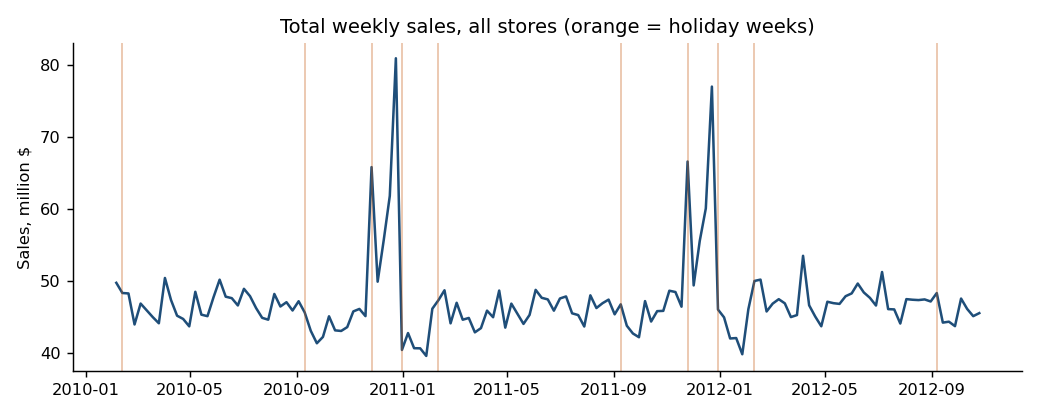

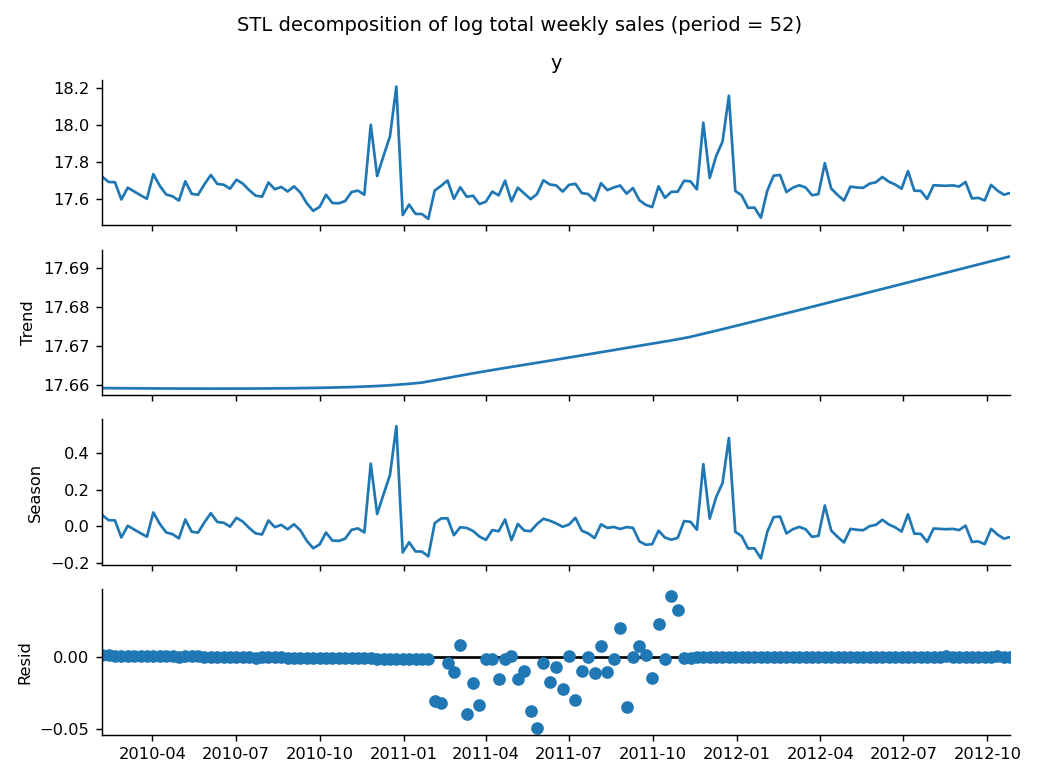

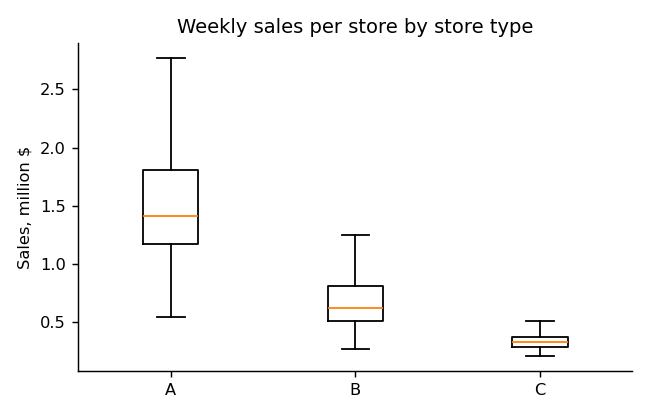

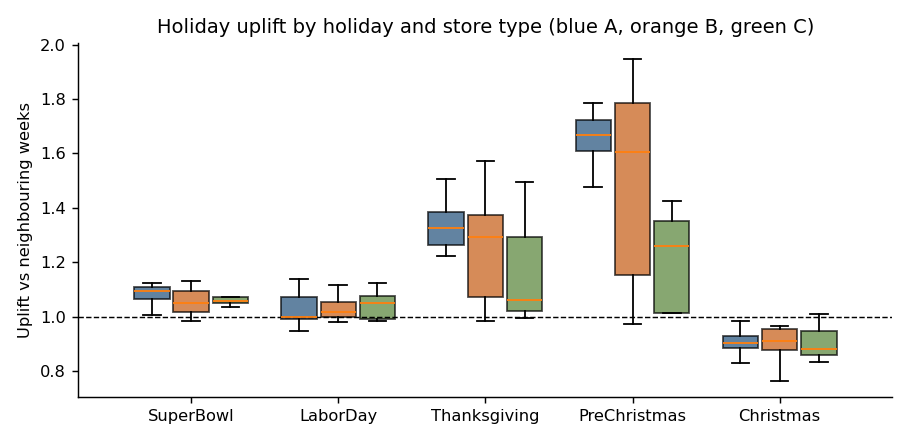

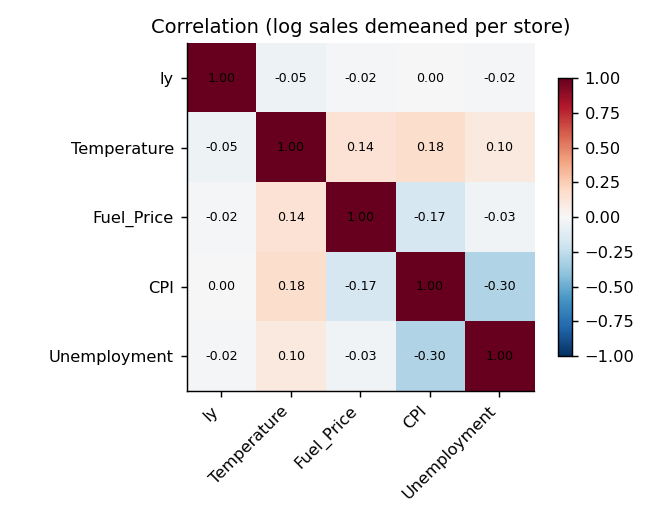

In [6]:
import pandas as pd
from IPython.display import Image, display
eda = P.stage_eda()
print(json.dumps(eda, indent=2))
display(pd.read_csv(C.OUT_DIR / "holiday_uplift_summary.csv").round(3))
for f in sorted(C.FIG_DIR.glob("0[1-6]_*.png")):
    display(Image(str(f)))

## 6. Baselines (rolling-origin, 4 folds). Takes a few minutes.

In [ ]:
cv_base = P.stage_baselines(with_prophet=not FAST)
cv_base.groupby("model").size()

NOTE: single-file variant detected. Store Type = sales tier from the first 52 weeks (proxy, not Walmart's official type); Size, Dept and MarkDown1-5 do not exist in this file; future drivers will be ASSUMED (see build_future_frame).


## 7. LightGBM and XGBoost

In [ ]:
cv_ml = P.stage_ml()
cv_ml.groupby("model").size()

## 8. Results table and Diebold-Mariano test (slide 14, H1)

In [ ]:
r = P.stage_evaluate()
display(r["overall"].round(3))
display(r["dm"].round(4))
print(json.dumps(r["summary"], indent=2))
print("Baseline fallbacks:"); display(pd.read_csv(C.OUT_DIR / "baseline_fallbacks.csv"))

## 9. SHAP (slide 15)

In [ ]:
ex = P.stage_explain()
display(ex["global"].head(10).round(3))
for f in [C.FIG_DIR / "07_shap_beeswarm.png", C.FIG_DIR / "08_shap_bar.png"]:
    display(Image(str(f)))

## 10. Build the agent's facts and ask a question (slide 16)

In [ ]:
P.stage_facts()
from wfa.agent.graph import run_agent
out = run_agent("What is the 12-week sales forecast for store 4, what drives it and how do holidays affect it?")
display(Markdown(out["report"]))
print("Faithfulness:", out["faithfulness"])
print("Attempts:", out["attempts"], "| model used:", out["model_used"], "| LLM stats:", out["llm_stats"])
print("Agent trace:")
for t in out["trace"]:
    print(" ", t["node"], "->", str(t["info"])[:100])

## 11. Agent evaluation (H3): about 10 stores x 3 questions
Uses your Gemini quota (about 30-90 calls). Responses are cached, so re-running is free. Keep `first_attempt_score` and `final_score` for the slide.

In [ ]:
from wfa.agent.evaluate_agent import run_agent_eval
ev = run_agent_eval()
ev.head(10)

## 12. Save everything
Downloads a zip of all results, charts and agent logs.

In [ ]:
import shutil
shutil.make_archive("results_outputs", "zip", str(C.OUT_DIR))
if IN_COLAB:
    files.download("results_outputs.zip")
print("saved results_outputs.zip")